In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
import matplotlib.pyplot as plt

In [2]:
# Import the data
data = pd.read_csv('crime_data.csv')

C:\Users\Spencer\AppData\Local\Temp\ipykernel_6996\563768368.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('crime_data.csv')


In [3]:
# Look at the data
data.head()

,INCIDENT_NO,DATE_REPORTED,DATE_FROM,DATE_TO,OFFENSE,LOCATION,WEAPONS,HOUR_FROM,HOUR_TO,LONGITUDE_X,LATITUDE_X
0,249000619,45299.08,45299.03,45299.04,DOMESTIC VIOLENCE,02-MULTI FAMILY APARTMENT,"40 - PERSONAL WEAPONS (HANDS, FEET, TEETH, ETC.)",48,51.0,-84.553662,39.143898
1,249000612,45298.94,45298.92,45298.93,FELONIOUS ASSAULT,01-SINGLE FAMILY HOME,"30 - BLUNT OBJECT (CLUB, HAMMER, ETC.)",2210,2220.0,-84.465827,39.138417
2,249000610,45298.90,45298.90,45298.9,DOMESTIC VIOLENCE,02-MULTI FAMILY APARTMENT,"40 - PERSONAL WEAPONS (HANDS, FEET, TEETH, ETC.)",2130,2130.0,-84.495313,39.124461
3,249000605,45298.85,45298.82,45298.85,AGGRAVATED ROBBERY,47-STREET,U - UNKNOWN,1945,2026.0,-84.511478,39.101485
4,249000604,45298.82,45298.81,45298.82,AGGRAVATED MENACING,47-STREET,12 - HANDGUN,1933,1934.0,-84.440842,39.115645


In [4]:
# Now we need to massage the data a little bit and prepare it for our nueral network
# The first through fourth and eight through eleven columns are good, they are numerical although NN like the 
# data to be between 0 and 1 so we'll just scale them
# We need to "label encode" columns five through seven
# In this first example our "y" is going to be "OFFENSE" and everything else will be "x"

x1 = np.array(data['INCIDENT_NO'])
# We have some errors trying to convert this first column to float
x1float = []
temp = 0
for val in x1:
    try:
        number = float(val)
    except ValueError:
        number = temp
        
    x1float.append(number)
    temp += 1
    
x1 = np.array(x1float) # There we go, now we have a column vector of numeric values, know we just need to scale it
x1 = x1/max(x1)

# Now for x2 - x4 and x8 - x11
x2 = np.array(data['DATE_REPORTED'], dtype=float)
x2 = x2/max(x2)

x3= np.array(data['DATE_FROM'], dtype=float)
x3= x3/max(x3)

x4= np.array(data['DATE_TO'])


x4float = []
temp = 0
for val in x4:
    try:
        number = float(val)
    except ValueError:
        number = temp
        
    x4float.append(number)
    temp += 1
    
x4 = np.array(x4float)
x4= x4/max(x4)

x8= np.array(data['HOUR_FROM'], dtype=float)
x8= x8/max(x8)

x9= np.array(data['HOUR_TO'], dtype=float)
x9= x9/max(x9)

x10= np.array(data['HOUR_TO'], dtype=float)
# For the location data we have negative number which we'll just take the absolute value for the ML portion
x10= abs(x10)/max(abs(x10))

x11= np.array(data['HOUR_TO'], dtype=float)
x11= abs(x11)/max(abs(x11))


In [5]:
# Now we can encode the label columns
location_encoder = LabelEncoder()
x6 = data['LOCATION']
x6 = location_encoder.fit_transform(x6)
print(np.unique(x6)) # Looks like we have 81 different LOCATION labels
x6orig = x6
x6 = x6/max(x6)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80]


In [6]:
x6labels = location_encoder.inverse_transform(x6orig)
x6labels # This is how you get back to the original labels

array(['02-MULTI FAMILY APARTMENT', '01-SINGLE FAMILY HOME',
       '02-MULTI FAMILY APARTMENT', ..., '02-MULTI FAMILY',
       '14-OTHER PUBLIC ACCESS BUILDING', '01-SINGLE FAMILY HOME'],
      dtype=object)

In [7]:
weapon_encoder = LabelEncoder()
x7 = data['WEAPONS']
x7 = weapon_encoder.fit_transform(x7)
print(np.unique(x7)) # 67 different weapons labels
x7 = x7/max(x7)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66]


In [8]:
# since we are going to try and predict the offense type then we'll also need to one-hot encode the offense data
offense_encoder = LabelEncoder()
y = data['OFFENSE']
y = offense_encoder.fit_transform(y)
yorig = y
onehot = OneHotEncoder()
y = onehot.fit_transform(y.reshape(-1,1)).toarray()
y.shape # What this does is it converts the column into an array where there is a row for each data point and the number 
# of columns is the number of unique labels, if the label at that data point matches the offense_encoder there is a one
# in that element, if not then there is a zero. We need the y data to be this way so that implimenting the NN is easy

(427695, 181)

In [9]:
x = np.stack((x1, x2, x3, x4, x6, x7, x8, x9, x10, x11))
x = x.T
x.shape

(427695, 10)

In [10]:
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size = 0.20, random_state=42)
xTrain, xVal, yTrain, yVal = train_test_split(xTrain, yTrain, test_size = .33, random_state = 21)
print(xTrain.shape)
print(yTrain.shape)

(229244, 10)
(229244, 181)


In [11]:
model = Sequential()
model.add(Dense(256, input_shape=(10,), activation='relu')) # the number of weights (256) can be adjusted for performance
model.add(Dense(512, activation='relu')) # same here, 512 can be adjusted
model.add(Dense(256, activation='relu')) # same here
model.add(Dense(181, activation='softmax')) # for the last layer we want the number of weights to match the size of y (181) with
# softmax activation since we are predicting classes this will result in a vector of probabilities in y
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               2816      
                                                                 
 dense_1 (Dense)             (None, 512)               131584    
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dense_3 (Dense)             (None, 181)               46517     
                                                                 
Total params: 312,245
Trainable params: 312,245
Non-trainable params: 0
_________________________________________________________________


In [12]:
# As you can see above, our model is a dense NN with 3 layers and an output layer, we have 312,245 total trainable weights
# Now all we need to do is train this bad boy
# 1st we compile it we need to use catergorical crossentropy for the loss function, we'll use the "adam" optimizer, and the metric we want to track
# during training is accuracy
model.compile(loss = 'categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
# During training we'll use an epoch of 100. This means that the model will be fit 100 times.
epochN = 20
# Now we can call the model fit function
history = model.fit(x = xTrain, y = yTrain, epochs=epochN, validation_data=(xVal, yVal))

Epoch 1/20
7164/7164 [==============================] - 16s 2ms/step - loss: 2.4469 - accuracy: 0.3383 - val_loss: 2.4299 - val_accuracy: 0.3410
Epoch 2/20
7164/7164 [==============================] - 15s 2ms/step - loss: 2.4289 - accuracy: 0.3398 - val_loss: 2.4292 - val_accuracy: 0.3410
Epoch 3/20
7164/7164 [==============================] - 15s 2ms/step - loss: 2.4269 - accuracy: 0.3398 - val_loss: 2.4269 - val_accuracy: 0.3410
Epoch 4/20
7164/7164 [==============================] - 15s 2ms/step - loss: 2.4261 - accuracy: 0.3398 - val_loss: 2.4254 - val_accuracy: 0.3410
Epoch 5/20
7164/7164 [==============================] - 15s 2ms/step - loss: 2.4254 - accuracy: 0.3398 - val_loss: 2.4254 - val_accuracy: 0.3410
Epoch 6/20
7164/7164 [==============================] - 15s 2ms/step - loss: 2.4254 - accuracy: 0.3398 - val_loss: 2.4251 - val_accuracy: 0.3410
Epoch 7/20
7164/7164 [==============================] - 15s 2ms/step - loss: 2.4250 - accuracy: 0.3398 - val_loss: 2.4248 - val_ac

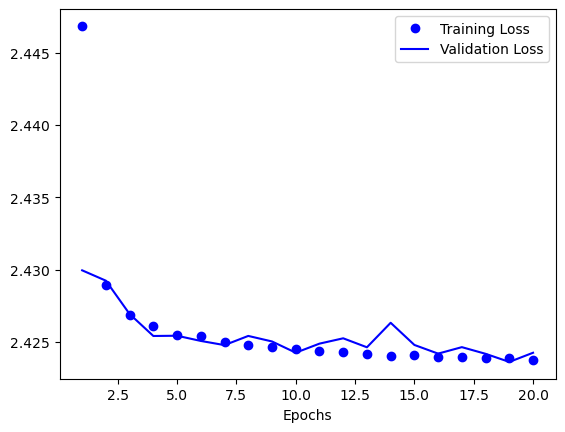

In [13]:
loss = history.history['loss']
valLoss = history.history['val_loss']
#acc = history.history['acc']
#valAcc = history.history['val_acc']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, valLoss, 'b', label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.show()

In [76]:
# Interesting! It looks like this NN cannot learn to predict the offense based on the data that we supplied it in x. Let's try
# to simplify it a little bit and see if we can predict if the crime is violent or nonviolent
# To do this, we need to make a new y, we'll look through the offenses and catagorize if the data is violent or not.
# Using this site as a reference for a definition of violent crime https://nij.ojp.gov/topics/crimes/violent-crime
#print(offense_encoder.inverse_transform(np.unique(yorig)))
a = offense_encoder.inverse_transform(np.unique(yorig)).T
a.shape
a.tofile("key.csv", sep=',')

In [77]:
key = pd.read_csv('key1.csv')
key.head()

,OFFENSE,VIOLENT
0,ABDUCTION,1
1,ABDUCTION - REMOVE FROM PLACE FOUND,1
2,ABDUCTION - RESTRAIN LIBERTY,1
3,AGG BURGLARY-ARMED W/ DEADLY WEAPON,1
4,ORDNANCE,1


In [78]:
# Alright! Now we have a key that we can use to make a new y
offense = np.array(data['OFFENSE'])
for i in range(len(offense)):
    if not isinstance(offense[i], str): # check for values that are not strings
        offense[i] = 'UNKOWN' # Make it unkown if it is not a string

In [79]:
offenseKey = np.array(key['OFFENSE'])
violentKey = np.array(key['VIOLENT'])
yNew = np.zeros((offense.shape[0], 2))
for i in range(len(offense)):
    for k in range(len(offenseKey)):
        if offenseKey[k] in offense[i]:
            yNew[i,:] = (violentKey[k], abs(violentKey[k] - 1))

In [99]:
print(sum(yNew[:,0])/len(yNew))
# Alright, it looks like about 35% of these crimes are violent
print(yNew.shape)
# Also, lets think about the x data a little. The incident number really doesn't tell us any thing about the crime so lets throw that out
# In addition, the dates reported don't really have any information about the crime unless we could get the day of the week. That might be 
# intersting to think about but no time right now. We'll keep location, weapon, hour_to, hour_from and the locations
xNew = np.stack((x6, x7, x8, x9, x10, x11))
xNew = xNew.T
print(xNew.shape)

0.3461929646126328
(427695, 2)
(427695, 6)


In [101]:
# Let's make a new model
xTrain, xTest, yTrain, yTest = train_test_split(xNew, yNew, test_size = 0.20, random_state=42, stratify=yNew)
xTrain, xVal, yTrain, yVal = train_test_split(xTrain, yTrain, test_size = .33, random_state = 21, stratify=yTrain)
print(xTrain.shape)
print(yTrain.shape)

(229244, 6)
(229244, 2)


In [102]:
model = Sequential()
model.add(Dense(128, input_shape=(6,), activation='relu')) # the number of weights (256) can be adjusted for performance
model.add(Dense(256, activation='relu')) # same here, 512 can be adjusted
model.add(Dense(62, activation='relu')) # same here
model.add(Dense(2, activation='softmax')) # for the last layer we want the number of weights to match the size of y (181) with
# softmax activation since we are predicting classes this will result in a vector of probabilities in y
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 128)               896       
                                                                 
 dense_13 (Dense)            (None, 256)               33024     
                                                                 
 dense_14 (Dense)            (None, 62)                15934     
                                                                 
 dense_15 (Dense)            (None, 2)                 126       
                                                                 
Total params: 49,980
Trainable params: 49,980
Non-trainable params: 0
_________________________________________________________________


In [103]:
model.compile(loss = 'categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
# During training we'll use an epoch of 100. This means that the model will be fit 100 times.
epochN = 20
# Now we can call the model fit function
history = model.fit(x = xTrain, y = yTrain, epochs=epochN, validation_data=(xVal, yVal))

Epoch 1/20
7164/7164 [==============================] - 13s 2ms/step - loss: 0.6453 - accuracy: 0.6529 - val_loss: 0.6448 - val_accuracy: 0.6529
Epoch 2/20
7164/7164 [==============================] - 12s 2ms/step - loss: 0.6449 - accuracy: 0.6529 - val_loss: 0.6447 - val_accuracy: 0.6529
Epoch 3/20
7164/7164 [==============================] - 12s 2ms/step - loss: 0.6452 - accuracy: 0.6529 - val_loss: 0.6450 - val_accuracy: 0.6529
Epoch 4/20
7164/7164 [==============================] - 12s 2ms/step - loss: 0.6459 - accuracy: 0.6529 - val_loss: 0.6495 - val_accuracy: 0.6529
Epoch 5/20
7164/7164 [==============================] - 12s 2ms/step - loss: 0.6495 - accuracy: 0.6527 - val_loss: 0.6455 - val_accuracy: 0.6529
Epoch 6/20
7164/7164 [==============================] - 13s 2ms/step - loss: 0.6566 - accuracy: 0.6473 - val_loss: 0.6568 - val_accuracy: 0.6529
Epoch 7/20
7164/7164 [==============================] - 13s 2ms/step - loss: 0.6656 - accuracy: 0.6342 - val_loss: 0.6447 - val_ac

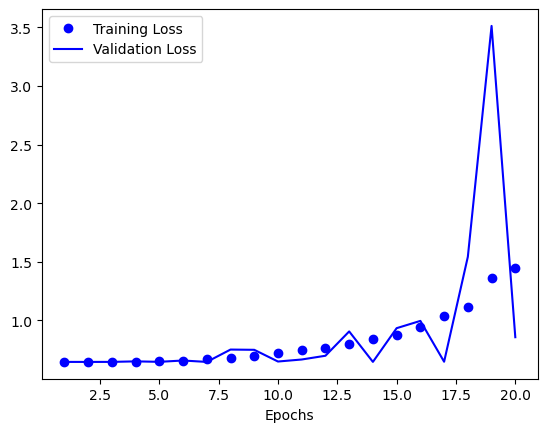

In [104]:
loss = history.history['loss']
valLoss = history.history['val_loss']
#acc = history.history['acc']
#valAcc = history.history['val_acc']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, valLoss, 'b', label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.show()

In [105]:
# So it looks like we don't have enough parameters to learn reliably if a crime is going to be violent or not. We need more parameters
# For example, if we had other information like breaking out the location into districts might prove useful or what officers where on duty
# Brain storm some ideas about what you think would improve these results and put it in your report